# **SPECTRA testing notebook**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import argparse
import yaml
import pickle
import torch
import networkx as nx
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
import os
import anndata as ad

ad.settings.allow_write_nullable_strings = True

# Suppress annoying warnings for a clean console
warnings.filterwarnings("ignore")

In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

12.1
Tesla V100-SXM2-32GB
Using device: cuda


In [4]:
from spectra.utils import set_seed
from spectra.data import data_preprocessing, build_model_dataloaders_perts_split, compute_weights
from spectra.model import SPECTRA

In [5]:
from spectra.evaluation import *

### **Load config file**

In [6]:
config_path = '../configs/vcc_config_final.yaml'

with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
print(yaml.dump(config, indent=2, sort_keys=False, default_flow_style=False))

project:
  name: test_reduced
  seed: 42
  deterministic: false
  use_wandb: false
data:
  adata_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/adata_vcc.h5ad
  gene_list_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_list-vcc.txt
  network_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/vcc_4/VCC_4_chitin.tsv
  scgpt_embeddings_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/scGPT_embeddings_all_genes.pkl
  gene_weights_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_weights-vcc.pkl
  split_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/vcc_4/VCC_4_split_indices.json
model:
  architecture: vcc_final_correct
  weights_folder_path: /group/sottoriva/michele.calabro/SPECTRA/weights/
  conv_type: FAGCN
  residual_weight: 0.8
  n_channels: 24
  dropout_p: 0.05
  num_node_features: 1
training:
  batch_size: 128
  lr: 0.001
  n_epochs: 20
  alpha: 4.4
  beta: 0.005
  gamma: 2.7
  test_ratio: 0.2
  val_ratio: 0.1



In [7]:
# Initialization & Seeding - set it to deterministic for reproducibility
set_seed(seed=config['project']['seed'], deterministic=config['project']['deterministic'])

### **Load files**

In [8]:
# Load adata
adata = sc.read_h5ad(config['data']['adata_path'])

# NOTE: for vcc dataset, log-transform is requested. 
# replogle already processed (replogle_preprocessing.ipynb)
adata = data_preprocessing(adata,
    logtransform=True, 
    min_cells_per_pert=50)
adata

View of AnnData object with n_obs × n_vars = 221193 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [9]:
# scGPT gene embeddings
with open(config['data']['scgpt_embeddings_path'], "rb") as f:
    scgpt_dict = pickle.load(f)

In [10]:
# load GRN
network_data = pd.read_csv(config['data']['network_path'], sep='\t')
G = nx.DiGraph()
for _, edge in network_data.iterrows():
    G.add_edge(edge['source'], edge['target'], weight=edge['weight'])

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
grn_genes = set(G.nodes)

In [11]:
# Filter adata to match final network genes
gene_list = grn_genes & set(adata.var_names)
if grn_genes != gene_list:
    print('WARNING: some genes in the provided gene list are not included in the grn, or the gene embeddings are missing; filtering them out...')
adata = adata[:, adata.var_names.isin(gene_list)]
G = G.subgraph(gene_list).copy()

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 4922
Number of edges: 151764


In [11]:
# save list of nodes
with open("/group/sottoriva/michele.calabro/SPECTRA/data/rep_rpe1/mysetgenes.txt", "w",) as f:
    for item in gene_list:
        f.write(f"{item}\n")

In [12]:
# Filter out perturbations that aren't in the gene list
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = list({
    pert for pert in perturbations
    if any(single_pert not in gene_list for single_pert in pert.split('+'))
})
if len(perts_not_included)>0:
    print('WARNING: some perturbed genes are not included in the GRN. Filtering these perturbation samples out...')
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()
adata

AnnData object with n_obs × n_vars = 221193 × 4922
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

### **Edge indices, embeddings matrix**
Other preparation steps fro SPECTRA

In [13]:
# sanity check
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [14]:
# Map Edge Index
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
edges = [(gene_to_idx[u], gene_to_idx[v]) for u, v in G.edges()]
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [15]:
# Build embedding matrix
scgpt_dict = {gene_to_idx[k]: v for k, v in scgpt_dict.items() if k in gene_to_idx}
scgpt_dim = len(next(iter(scgpt_dict.values())))
embedding_matrix = torch.zeros((num_nodes, scgpt_dim))
for gene_id, emb in scgpt_dict.items():
    embedding_matrix[gene_id] = torch.tensor(emb, dtype=torch.float32)

### **Dataloaders creation**

In [16]:
# perturbations = list(adata.obs['target_gene'].unique())
# perturbations.remove('non-targeting')
perturbations = sorted(pert for pert in adata.obs["target_gene"].unique() if pert != "non-targeting")

# Merge config dictionaries for the model/dataloaders
model_config = {**config['model'], **config['training']}
model_config['dataset_size'] = adata.shape[0]
model_config['pert_to_idx'] = {pert: i for i, pert in enumerate(perturbations)}

In [17]:
from spectra.data import build_model_dataloaders_from_perts_list

train_loader, val_loader, test_loader, _, _, _, train_adata, val_adata, test_adata = build_model_dataloaders_from_perts_list(adata, model_config, config['data']['split_path'])

Total Unique Perturbations: 148
Train set: 108 perts | 138336 cells
Val set: 20 perts | 25505 cells
Test set: 20 perts | 19176 cells


In [18]:
# Load WMSE Weights
weights_path = config['data']['gene_weights_path']
if os.path.exists(weights_path):
    print('found already existing gene weights dictionary! Loading...')
    with open(weights_path, 'rb') as f:
        gene_weights = pickle.load(f)
else:
    print('No gene weights dictionary found. Calculating...')
    gene_weights = compute_weights(train_adata, cells_per_pert=256)
    with open(weights_path, 'wb') as f:
        pickle.dump(gene_weights, f)

found already existing gene weights dictionary! Loading...


### **Model initialization**

In [19]:
model = SPECTRA(
    edge_index=edge_index, 
    num_nodes=num_nodes, 
    device=device, 
    config=model_config,
    gene_embeddings=embedding_matrix,
    gene_names=adata.var_names,
    gene_weights=gene_weights
).to(device)
print(model)

SPECTRA(
  (gene_embeddings): Embedding(4922, 512)
  (project_gene): Linear(in_features=512, out_features=24, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=24, bias=True)
    (shift): Linear(in_features=1, out_features=24, bias=True)
  )
  (add_norm): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=24, bias=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(24)
    (conv2): DirFAGCNConv(24)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=24, out_features=24, bias=True)
    (proj_logstd): Linear(in_features=24, out_features=24, bias=True)
  )
  (gex_decoder): FeatureDecoder(
    (conv1): DirFAGCNConv(24)
    (conv2): DirFAGCNConv(24)
    (conv3): DirFAGCNConv(24)

## **Testing**

In [20]:
#model.load_state_dict(torch.load("/group/sottoriva/michele.calabro/SPECTRA/weights/sweep/best_model_medium_filtering_wer5qwla.pth")) 
model.load_state_dict(torch.load('/group/sottoriva/michele.calabro/SPECTRA/weights/sweep/vcc/best_model_vcc_final_correct_f5rerm9v.pth'))

<All keys matched successfully>

In [21]:
model.eval()

SPECTRA(
  (gene_embeddings): Embedding(4922, 512)
  (project_gene): Linear(in_features=512, out_features=24, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=24, bias=True)
    (shift): Linear(in_features=1, out_features=24, bias=True)
  )
  (add_norm): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=24, bias=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(24)
    (conv2): DirFAGCNConv(24)
    (ln1): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((24,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=24, out_features=24, bias=True)
    (proj_logstd): Linear(in_features=24, out_features=24, bias=True)
  )
  (gex_decoder): FeatureDecoder(
    (conv1): DirFAGCNConv(24)
    (conv2): DirFAGCNConv(24)
    (conv3): DirFAGCNConv(24)

In [22]:
##### test adata

N_MIN_SAMPLES = 30

# removing less abundant perturbations
counts = test_adata.obs['target_gene'].value_counts()
counts = counts[counts >= N_MIN_SAMPLES]

# creation of dict: for each perturbation how many cells to generate
gene_counts_dict = counts.drop('non-targeting').to_dict() 

# test adata
real_adata = test_adata[test_adata.obs['target_gene'].isin(counts.index)]
control_adata = real_adata[real_adata.obs['target_gene']=='non-targeting']
real_adata

View of AnnData object with n_obs × n_vars = 24336 × 4922
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'

In [31]:
with open('../../data/rep_rpe1/gene_counts_dict.pkl', 'wb') as f:
    pickle.dump(gene_counts_dict, f)

In [30]:
control_adata.write('../../results/rpe1/control_adata.h5ad')

## **Multiple runs data generation**
For complete benchamrk (check `benchmark.ipynb`)

In [ ]:
###########################################################################################
############################ generate n_runs SPECTRA outputs ##############################
###########################################################################################
from tqdm import tqdm
from spectra.model import generate_from_control

N_RUNS = 10
OUTPUT_DIR = '../results/final_vcc/wilcoxon/'
for i in tqdm(range(N_RUNS)):
    pred_adata = generate_from_control(gene_counts_dict, control_adata, model, gene_to_idx, add_control=False)
    pred_adata.write(f'{OUTPUT_DIR}/pred_adata-SPECTRA-{i}.h5ad')

100%|██████████| 10/10 [08:28<00:00, 50.82s/it]


In [35]:
###########################################################################################
############################ generate n_runs baseline outputs #############################
###########################################################################################
from tqdm import tqdm
from spectra.evaluation import generate_adata_baseline

N_RUNS = 10
OUTPUT_DIR = '/group/sottoriva/michele.calabro/SPECTRA/results/rpe1'
for i in tqdm(range(N_RUNS)):
    pred_adata = generate_adata_baseline(gene_counts_dict, train_adata)
    pred_adata.write(f'{OUTPUT_DIR}/pred_adata-baseline-{i}.h5ad')

100%|██████████| 10/10 [00:24<00:00,  2.48s/it]


## **Single run benchmark**

In [53]:
from spectra.model import generate_from_control

# SPECTRA data generation
pred_adata = generate_from_control(gene_counts_dict, control_adata, model, gene_to_idx, add_control=True)
pred_adata

100%|██████████| 20/20 [00:50<00:00,  2.52s/it]


AnnData object with n_obs × n_vars = 24336 × 4922
    obs: 'target_gene'

In [54]:
from spectra.evaluation import generate_adata_baseline

# pseudobulk baseline
pred_adata_2 = generate_adata_baseline(gene_counts_dict, train_adata)

# Append the non-targeting controls to the example anndata if they're missing - needed for DEGs overlap metrics
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata_2.obs["target_gene"].unique():
    assert np.all(pred_adata_2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata_2 = ad.concat([pred_adata_2, ntc_adata,])
del ntc_adata
pred_adata_2

100%|██████████| 20/20 [00:00<00:00, 180.12it/s]


AnnData object with n_obs × n_vars = 24336 × 4922
    obs: 'target_gene'

In [55]:
real_adata.write('real_adata.h5ad')
pred_adata.write('pred_adata-SPECTRA.h5ad')
pred_adata_2.write('pred_adata-baseline.h5ad')

In [56]:
!python ../scripts/evaluate.py \
    --real real_adata.h5ad \
    --pred pred_adata-SPECTRA.h5ad \
      pred_adata-baseline.h5ad \
    --metrics kldiv \
    --top_DEGs 50

[*] Loading real dataset from: real_adata.h5ad
[*] Loading prediction for model 'SPECTRA': pred_adata-SPECTRA.h5ad
    -> Calculating kldiv...
[*] Loading prediction for model 'baseline': pred_adata-baseline.h5ad
    -> Calculating kldiv...
[*] All evaluations complete.


## **Interpretability analysis**

In [23]:
from spectra.evaluation import *

TARGET_GENE = 'MDM2'
MIN_SIGNAL = 1e-3
K_EDGES = 20

# Forward pass & extract attention matrices
x, pert = prepare_perturbation_batch(TARGET_GENE, control_adata, model, n_cells=256)
A1, A2, A3, y_hat, x_hat = model.compute_downstream_path_matrices(x, pert)
A_matrices = [A1, A2, A3]

In [25]:
# Extract network & render Sankey
hop_genes, edges, weights, net_genes = get_cascade_network(
    A_matrices, TARGET_GENE, model, minimum_signal=MIN_SIGNAL, K_edges=K_EDGES
)
background_genes = real_adata.var_names.dropna().astype(str).tolist()
gene_functions = get_gene_ontology(net_genes, TARGET_GENE, background_genes, top_n=20)
plot_sankey(TARGET_GENE, hop_genes, edges, weights, gene_functions, out_dir='cascade_plots')

Querying Gene Ontology...


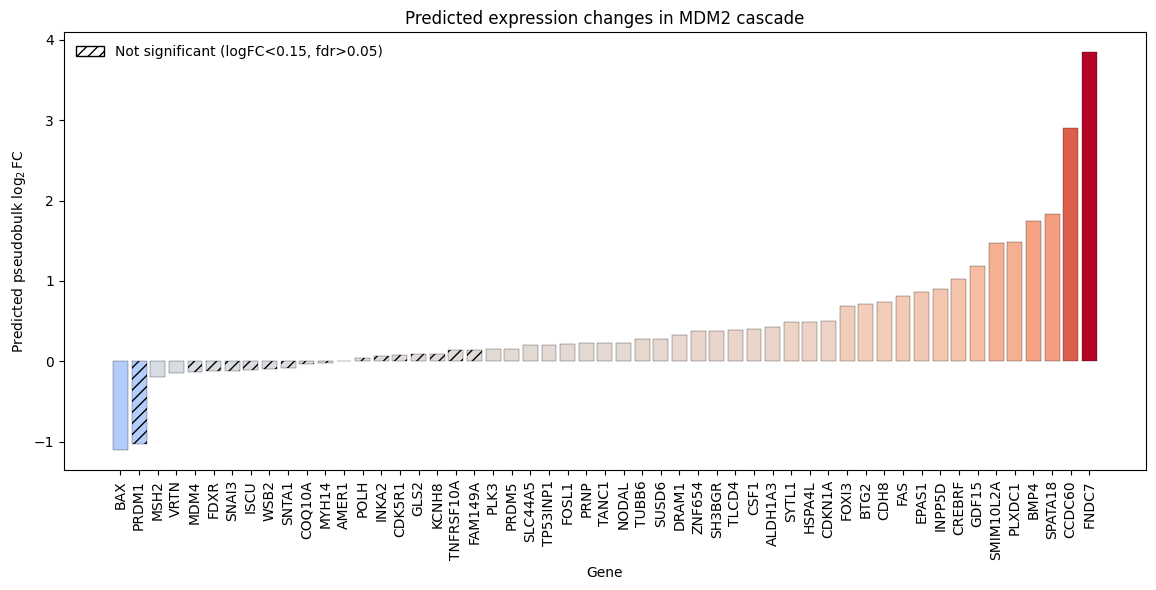

In [ ]:
# pseudobulk LogFC and Wilcoxon DE statistics
B = x.shape[0]
N = model.num_nodes
pseudobulk_pert = get_pseudobulk(y_hat, B, N)
pseudobulk_ctrl = get_pseudobulk(x, B, N)
pvals, qvals = get_predicted_de_stats(y_hat, x, model)

plot_cascade_logfc(
    net_genes, model, pseudobulk_pert, pseudobulk_ctrl, TARGET_GENE,
    qvals=qvals, fdr_threshold=0.05, logfc_threshold=0.15, out_dir='cascade_plots'
)

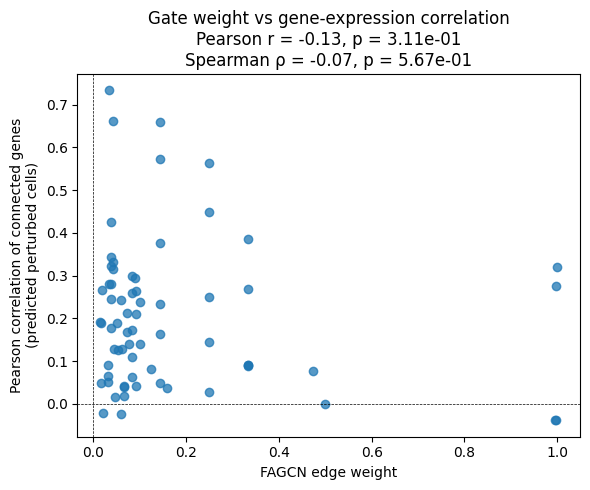

In [ ]:
# Gate weight vs coexpression correlation
corr_stats = plot_gate_vs_coexpression(TARGET_GENE, edges, y_hat, model, B=B)

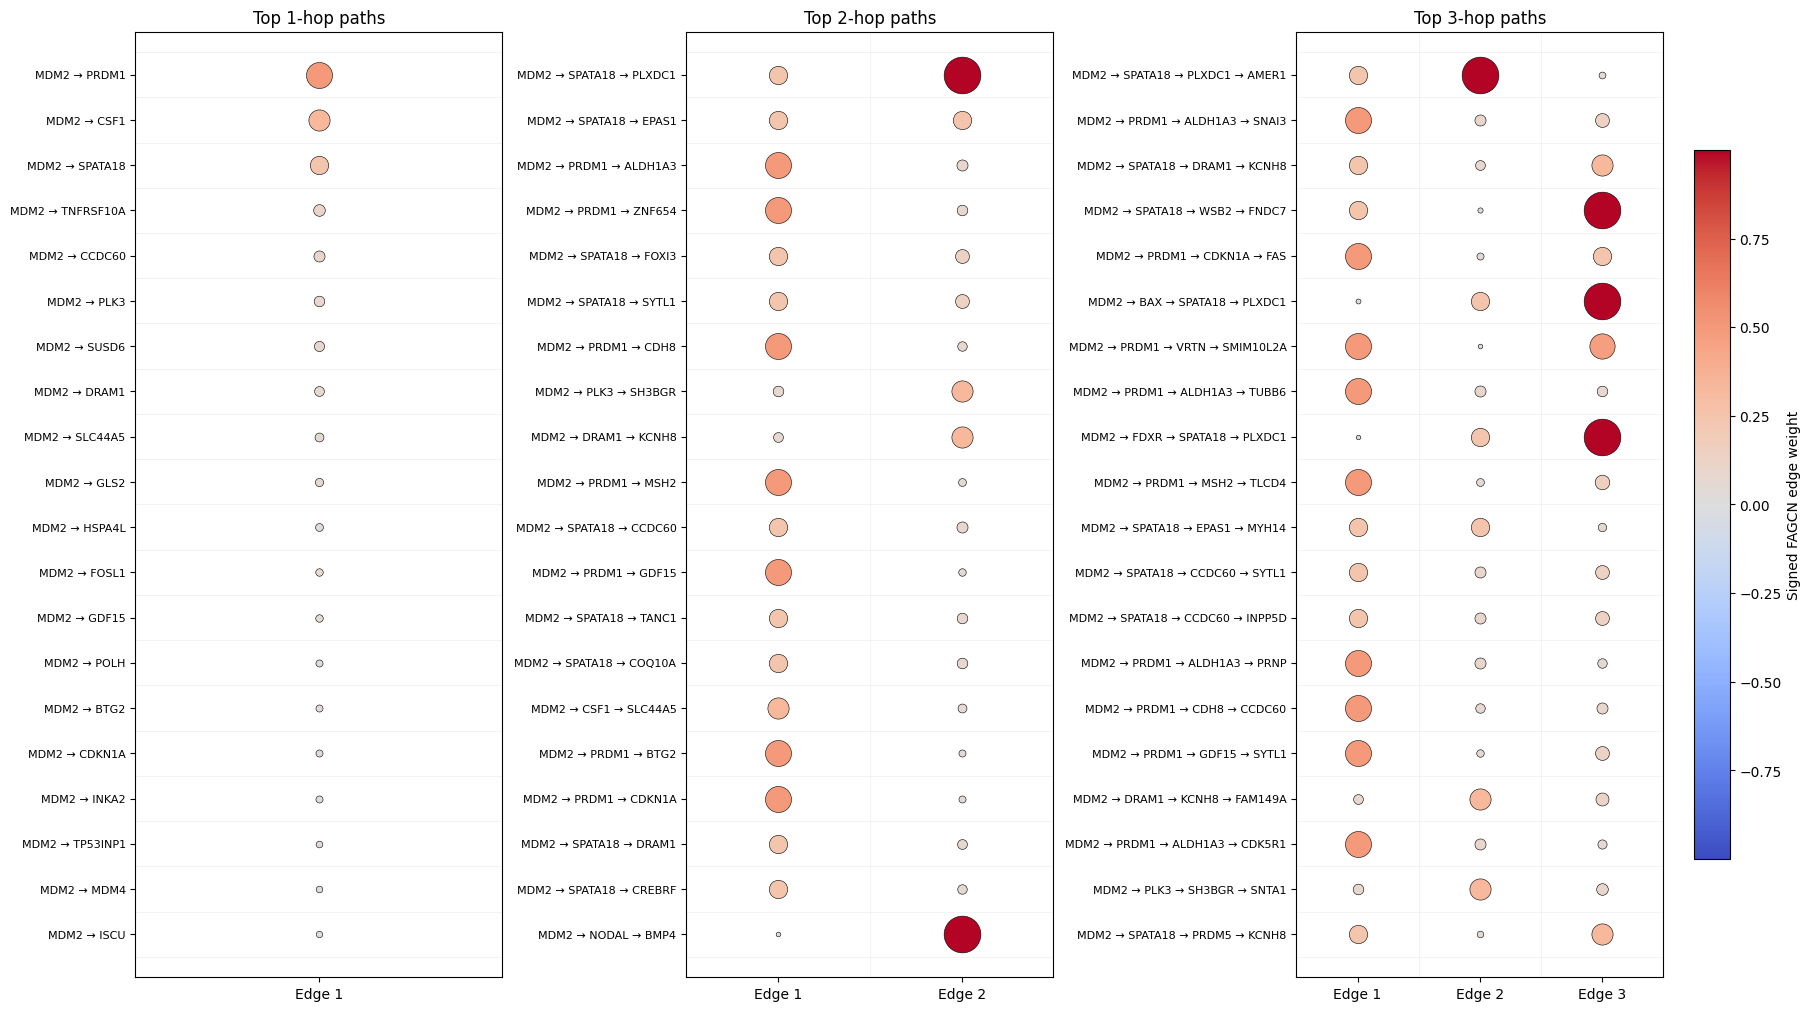

In [ ]:
# Complete Path Dot-Heatmaps
top_paths = get_top_complete_paths(
    A_matrices, TARGET_GENE, model, K_paths=K_EDGES, minimum_signal=MIN_SIGNAL
)
plot_complete_path_dot_heatmaps(top_paths, TARGET_GENE, out_dir='cascade_plots')

## **Association between FAGCN edge weights and gene–gene coexpression**

In [42]:
genes = ['CDKN1A', 'PHLDA3','PRAP1', 'RPS27L', 'MDM2', 'BAX', 'NUPR1', 'DDIT4', 'PLK3', 'PLK2', 'SESN2', 'TRIAP1', 'EDA2R', 'PMAIP1']

In [52]:
from tqdm import tqdm

results_correlation = {}
for target_gene in tqdm(genes):

    if target_gene not in model.gene_to_idx:
        print(f"Gene '{target_gene}' not found in gene mapping.")
        continue

    x, pert = prepare_perturbation_batch(target_gene, control_adata, model, n_cells=256)
    A_1, A_2, A_3, y_hat, x_hat = model.compute_downstream_path_matrices(x, pert)
    A_matrices = [A_1, A_2, A_3]
    hop_genes, edges, weights, net_genes = get_cascade_network(
        A_matrices, target_gene, model, MIN_SIGNAL, K_EDGES
    )

    B = x.shape[0]
    results_correlation[target_gene] = plot_gate_vs_coexpression(target_gene, edges, y_hat, model, B, plot=False)

df_correlation = pd.DataFrame.from_dict(results_correlation, orient="index")
df_correlation.index.name = "target_gene"
df_correlation = df_correlation.sort_values(by="pearson_p", ascending=True)
df_correlation.head()

 21%|██▏       | 3/14 [00:07<00:26,  2.43s/it]

Gene 'RPS27L' not found in gene mapping.


 86%|████████▌ | 12/14 [00:29<00:05,  2.66s/it]

Gene 'EDA2R' not found in gene mapping.


100%|██████████| 14/14 [00:33<00:00,  2.43s/it]


,pearson_r,pearson_p,spearman_r,spearman_p,n_edges
target_gene,,,,,
NUPR1,0.762235,3.095227e-10,0.435085,1.998581e-03,48
PMAIP1,0.613884,1.100341e-09,0.533243,2.971320e-07,81
PLK3,0.695191,3.240173e-07,0.318302,3.994198e-02,42
PRAP1,0.579020,8.536668e-06,0.539095,4.473340e-05,51
SESN2,0.415684,1.258060e-04,0.262402,1.870189e-02,80


## **Other plots - pred vs real DEGs gene expression**
Comparing top DEGs gene expression against ground truth

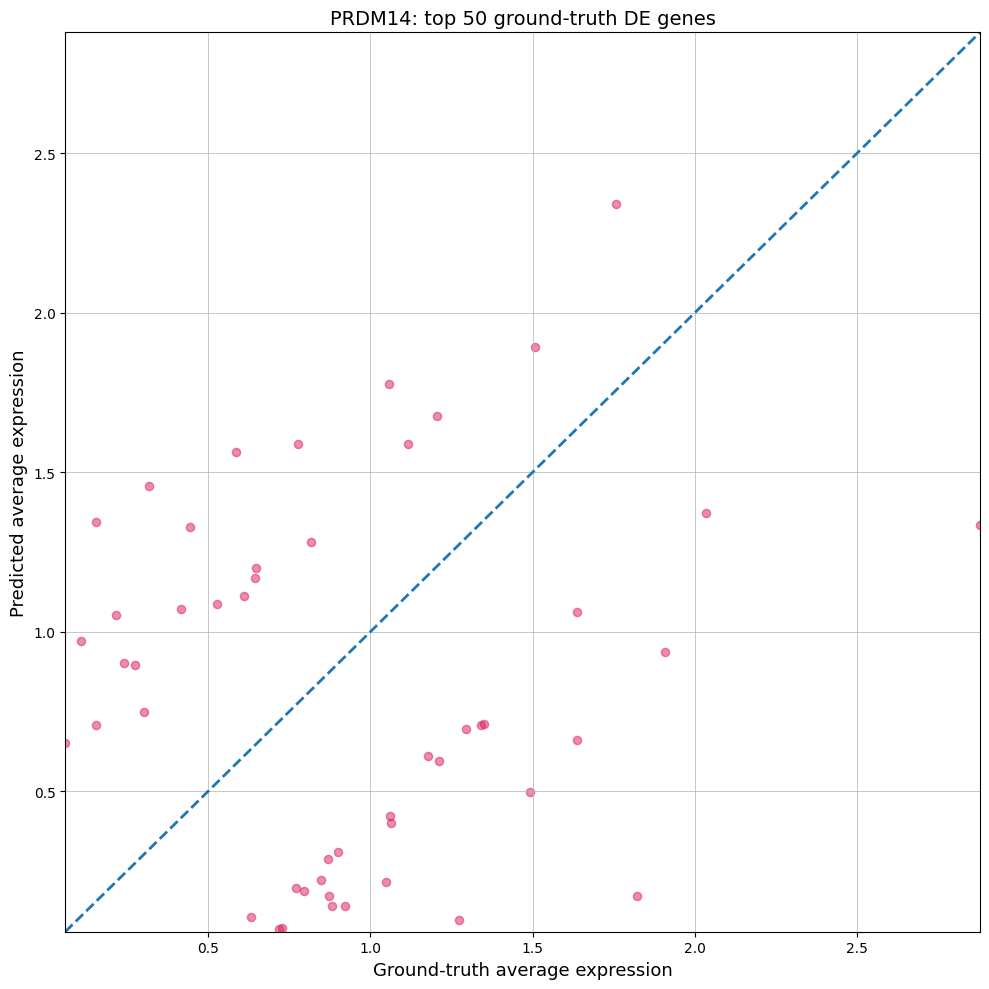

In [67]:
from spectra.evaluation import plot_top_de_gene_expression

# Real vs Pred DE comparison
df_top = plot_top_de_gene_expression(
    gt_adata=real_adata,
    pred_adata=pred_adata,
    perturbation="PRDM14",
    n_top_DEGs=50,
    pert_key="target_gene",
    control_label="non-targeting",
)